In [2]:
import cirq
from cirq.circuits import InsertStrategy
from cirq.contrib.svg import SVGCircuit

from quantum_logical.gates import (
    cnot_operator,
    hadamard_operator,
    state_swap,
)

# Define qutrits
q0 = cirq.LineQid(0, dimension=2)
q1 = cirq.LineQid(1, dimension=2)
q2 = cirq.LineQid(2, dimension=2)
q3 = cirq.LineQid(3, dimension=2)
q4 = cirq.LineQid(4, dimension=2)
q5 = cirq.LineQid(5, dimension=2)


# Define gates
hadamard = cirq.MatrixGate(hadamard_operator(3).full(), qid_shape=(3,), name="H")
x_2_1 = cirq.MatrixGate(state_swap(3,2).full(), qid_shape=(3,), name="X_{1,2}")
cnot_1 = cirq.MatrixGate(cnot_operator(2, 3, 0, 1, 1).full(), qid_shape=(3,3), name="CNOT_1")
cnot_2 = cirq.MatrixGate(cnot_operator(2, 3, 0, 1, 2).full(), qid_shape=(3,3), name="CNOT_2")
# iSwap_1 = cirq.MatrixGate(iSwap_operator(3,1).full(), qid_shape=(3,3), name="iSWAP_1")
# iSwap_2 = cirq.MatrixGate(iSwap_operator(3,2).full(), qid_shape=(3,3), name="iSWAP_2")



In [3]:
circuit = cirq.Circuit(
    cirq.H.on(q0),
    cirq.H.on(q1),
    cirq.H.on(q2),
    cirq.CNOT.on(q0,q3),
    cirq.CNOT.on(q1,q3),
    cirq.CNOT.on(q1,q4),
    cirq.CNOT.on(q2,q4),
    cirq.H.on(q0),
    cirq.H.on(q1),
    cirq.H.on(q2),
    strategy=InsertStrategy.NEW_THEN_INLINE
)

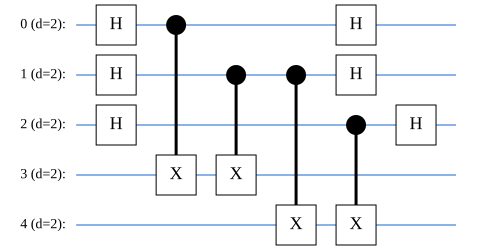

In [4]:
SVGCircuit(circuit)

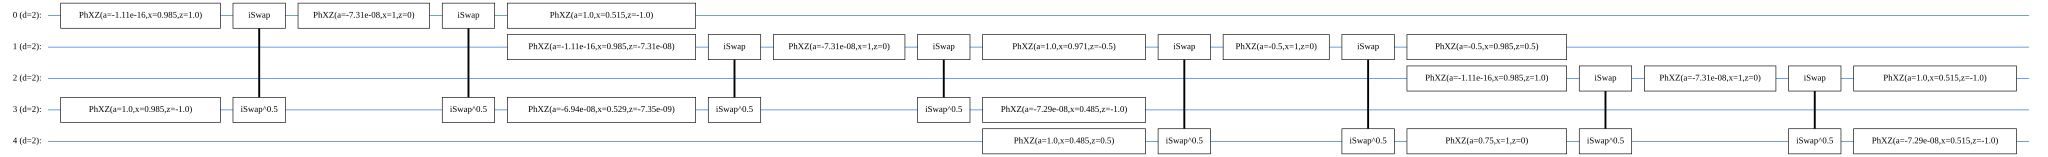

In [5]:
transpiled_circuit = cirq.optimize_for_target_gateset(circuit=circuit.freeze(), gateset= cirq.SqrtIswapTargetGateset())
SVGCircuit(transpiled_circuit)